# 🌐 Introduction to Network Analysis
### A Hands-On Guide for Beginners

---


**What you'll learn in this notebook:**
- What networks are and why they matter
- How to build and visualize networks with Python
- Key metrics that describe networks (degree, centrality, clustering)
- How to interpret network structure
- Hands-on exercises to test your understanding

**Prerequisites:** Basic Python knowledge. No prior network analysis experience needed.

---

## 📦 Part 0: Setup

Let's install and import everything we need. We'll use **NetworkX**, the most popular Python library for network analysis.

In [ ]:
# Install required libraries (already available in Colab, but just in case)
!pip install networkx matplotlib numpy pandas --quiet

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import random
from collections import Counter

# Set a clean visual style
plt.rcParams['figure.figsize'] = (10, 7)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("✅ All libraries loaded successfully!")
print(f"   NetworkX version: {nx.__version__}")

✅ All libraries loaded successfully!
   NetworkX version: 3.6.1


---
## 🧠 Part 1: What Is a Network?

### The Big Idea

A **network** (also called a **graph**) is simply a collection of **things** and the **connections between them**.

In formal terms:
- The "things" are called **nodes** (or vertices)
- The "connections" are called **edges** (or links)

### Real-World Examples

| Network | Nodes | Edges |
|---------|-------|-------|
| Social media | People | Friendships / Follows |
| Internet | Websites | Hyperlinks |
| Airport system | Cities | Flight routes |
| Biology | Proteins | Physical interactions |
| University | Students | Shared classes |
| Disease spread | People | Contact / Transmission |

**Think of it this way:** Anytime you have relationships between entities, you have a network.

### Let's Build Our First Network!

Imagine a small friend group. We'll create a network where each person is a node and each friendship is an edge.

In [ ]:
# Create an empty graph
G = nx.Graph()

# Add people (nodes)
people = ["Alice", "Bob", "Carol", "David", "Eve", "Frank"]
G.add_nodes_from(people)

# Add friendships (edges)
friendships = [
    ("Alice", "Bob"),
    ("Alice", "Carol"),
    ("Bob", "Carol"),
    ("Bob", "David"),
    ("Carol", "David"),
    ("David", "Eve"),
    ("Eve", "Frank"),
    ("David", "Frank"),
]
G.add_edges_from(friendships)

# Print basic info
print(f"Number of people (nodes): {G.number_of_nodes()}")
print(f"Number of friendships (edges): {G.number_of_edges()}")
print(f"\nPeople: {list(G.nodes())}")
print(f"Friendships: {list(G.edges())}")

Number of people (nodes): 6
Number of friendships (edges): 8

People: ['Alice', 'Bob', 'Carol', 'David', 'Eve', 'Frank']
Friendships: [('Alice', 'Bob'), ('Alice', 'Carol'), ('Bob', 'Carol'), ('Bob', 'David'), ('Carol', 'David'), ('David', 'Eve'), ('David', 'Frank'), ('Eve', 'Frank')]


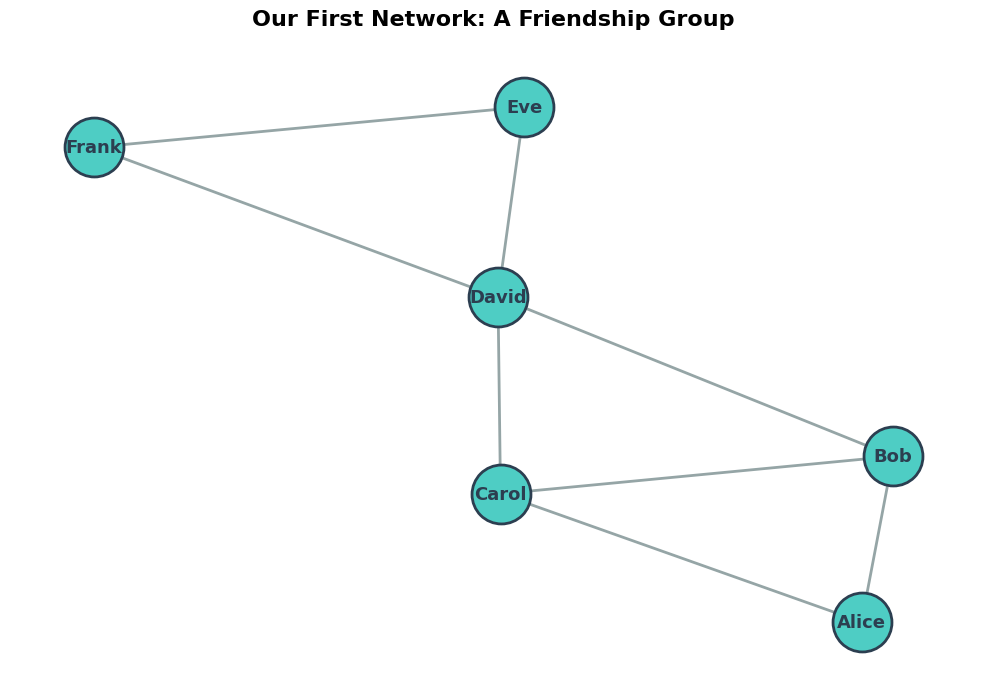

In [ ]:
# Visualize the friendship network
fig, ax = plt.subplots(figsize=(10, 7))

pos = nx.spring_layout(G, seed=42)  # Position nodes nicely

nx.draw_networkx_nodes(G, pos, node_color='#4ECDC4', node_size=1800,
                       edgecolors='#2C3E50', linewidths=2, ax=ax)
nx.draw_networkx_edges(G, pos, edge_color='#95A5A6', width=2, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=13, font_weight='bold',
                        font_color='#2C3E50', ax=ax)

ax.set_title("Our First Network: A Friendship Group", fontsize=16, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

### 💬 Discussion Questions
1. Who has the most friends in this network?
2. If Alice wanted to send a message to Frank, what's the shortest path?
3. Are there any "bridge" people who connect different sub-groups?

---
## 📊 Part 2: Types of Networks

Not all networks are the same. Let's explore the most common types.

### 2.1 Undirected vs. Directed Networks

- **Undirected:** Connections go both ways (e.g., Facebook friendships — if I'm your friend, you're mine)
- **Directed:** Connections have a direction (e.g., Twitter follows — I can follow you without you following me back)

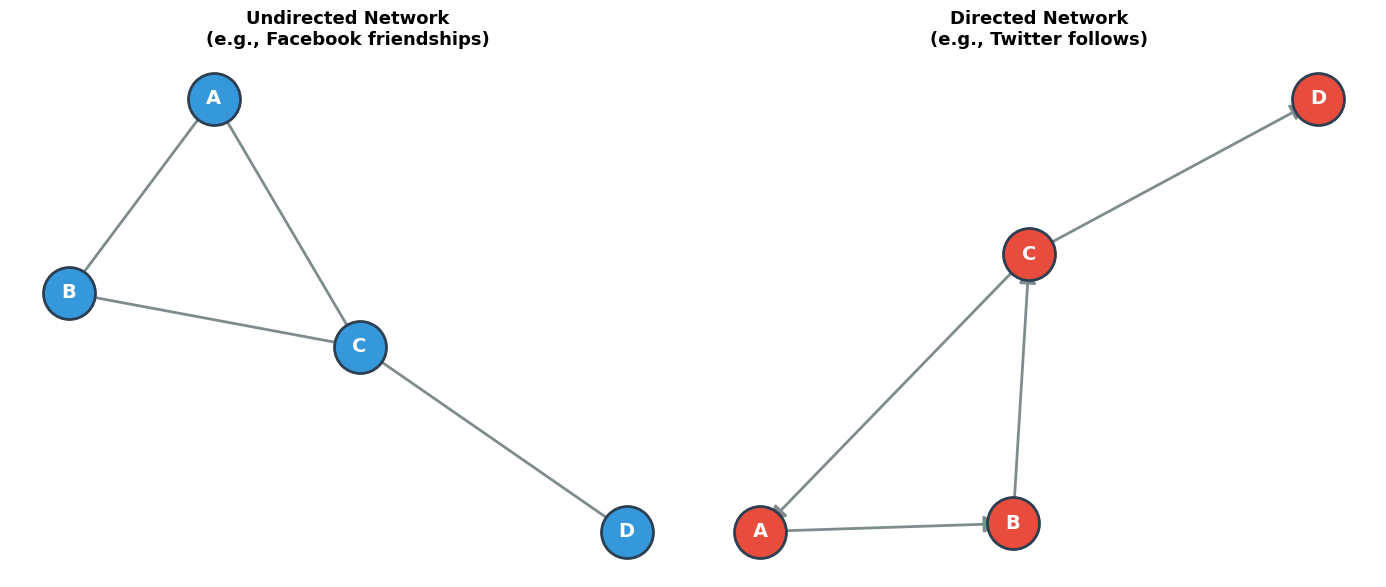

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Undirected graph ---
G_undirected = nx.Graph()
G_undirected.add_edges_from([("A", "B"), ("B", "C"), ("A", "C"), ("C", "D")])
pos_u = nx.spring_layout(G_undirected, seed=1)

nx.draw_networkx_nodes(G_undirected, pos_u, node_color='#3498DB', node_size=1400,
                       edgecolors='#2C3E50', linewidths=2, ax=axes[0])
nx.draw_networkx_edges(G_undirected, pos_u, edge_color='#7F8C8D', width=2, ax=axes[0])
nx.draw_networkx_labels(G_undirected, pos_u, font_size=14, font_weight='bold',
                        font_color='white', ax=axes[0])
axes[0].set_title("Undirected Network\n(e.g., Facebook friendships)", fontsize=13, fontweight='bold')
axes[0].axis('off')

# --- Directed graph ---
G_directed = nx.DiGraph()
G_directed.add_edges_from([("A", "B"), ("B", "C"), ("C", "A"), ("C", "D")])
pos_d = nx.spring_layout(G_directed, seed=1)

nx.draw_networkx_nodes(G_directed, pos_d, node_color='#E74C3C', node_size=1400,
                       edgecolors='#2C3E50', linewidths=2, ax=axes[1])
nx.draw_networkx_edges(G_directed, pos_d, edge_color='#7F8C8D', width=2,
                       arrows=True, arrowsize=25, ax=axes[1])
nx.draw_networkx_labels(G_directed, pos_d, font_size=14, font_weight='bold',
                        font_color='white', ax=axes[1])
axes[1].set_title("Directed Network\n(e.g., Twitter follows)", fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### 2.2 Weighted vs. Unweighted Networks

- **Unweighted:** All connections are equal
- **Weighted:** Connections have a strength or cost (e.g., distance between cities, number of emails exchanged)

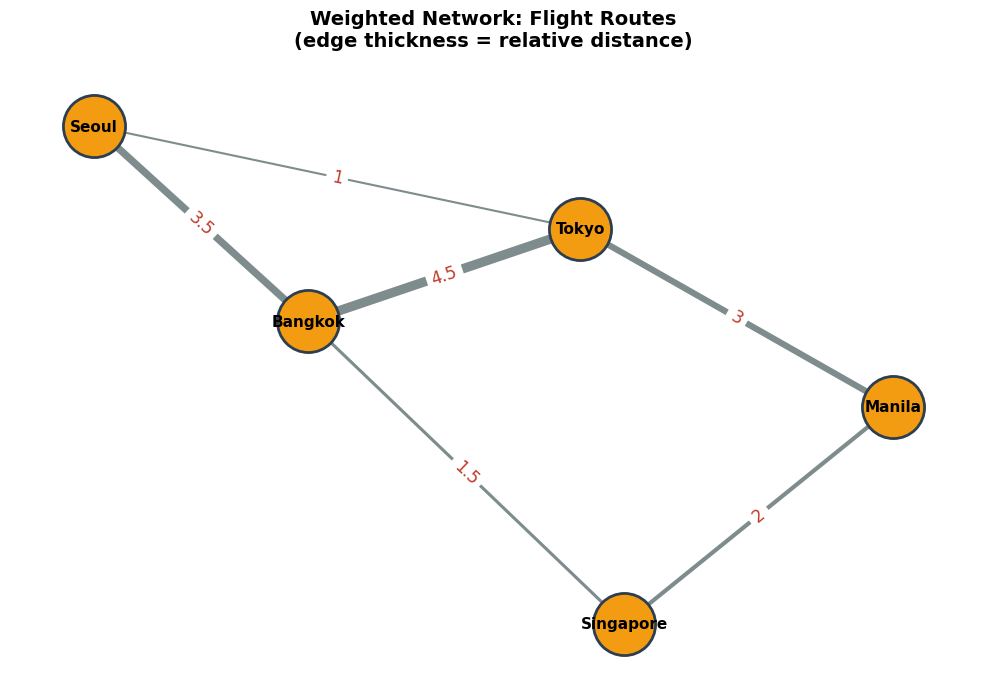

In [ ]:
# Weighted network: cities with flight distances (in hundreds of km)
G_weighted = nx.Graph()
G_weighted.add_edge("Manila", "Tokyo", weight=3)
G_weighted.add_edge("Manila", "Singapore", weight=2)
G_weighted.add_edge("Tokyo", "Seoul", weight=1)
G_weighted.add_edge("Singapore", "Bangkok", weight=1.5)
G_weighted.add_edge("Tokyo", "Bangkok", weight=4.5)
G_weighted.add_edge("Seoul", "Bangkok", weight=3.5)

fig, ax = plt.subplots(figsize=(10, 7))
pos_w = nx.spring_layout(G_weighted, seed=10)

# Draw edges with thickness proportional to weight
edges = G_weighted.edges(data=True)
weights = [d['weight'] for _, _, d in edges]

nx.draw_networkx_nodes(G_weighted, pos_w, node_color='#F39C12', node_size=2000,
                       edgecolors='#2C3E50', linewidths=2, ax=ax)
nx.draw_networkx_edges(G_weighted, pos_w, edge_color='#7F8C8D',
                       width=[w * 1.5 for w in weights], ax=ax)
nx.draw_networkx_labels(G_weighted, pos_w, font_size=11, font_weight='bold', ax=ax)

# Add weight labels
edge_labels = {(u, v): f"{d['weight']}" for u, v, d in edges}
nx.draw_networkx_edge_labels(G_weighted, pos_w, edge_labels=edge_labels,
                              font_size=12, font_color='#C0392B', ax=ax)

ax.set_title("Weighted Network: Flight Routes\n(edge thickness = relative distance)",
            fontsize=14, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

---
## 🔑 Part 3: Key Network Metrics (The "Vital Signs" of a Network)

Just like a doctor checks your heart rate and blood pressure, network analysts have standard metrics to understand a network's structure.

Let's go back to our friendship network and measure it.

### 3.1 Degree: How Connected Is Each Node?

The **degree** of a node is simply the number of edges connected to it.

**In plain English:** How many friends does each person have?

In [ ]:
# Calculate degree for each person
print("=" * 40)
print("DEGREE: Number of Friends")
print("=" * 40)

degree_dict = dict(G.degree())
for person, degree in sorted(degree_dict.items(), key=lambda x: -x[1]):
    bar = '█' * degree
    print(f"  {person:>8}: {degree} friends  {bar}")

print(f"\n  Average degree: {sum(degree_dict.values()) / len(degree_dict):.1f}")
print(f"  Most connected: {max(degree_dict, key=degree_dict.get)}")

DEGREE: Number of Friends
     David: 4 friends  ████
       Bob: 3 friends  ███
     Carol: 3 friends  ███
     Alice: 2 friends  ██
       Eve: 2 friends  ██
     Frank: 2 friends  ██

  Average degree: 2.7
  Most connected: David


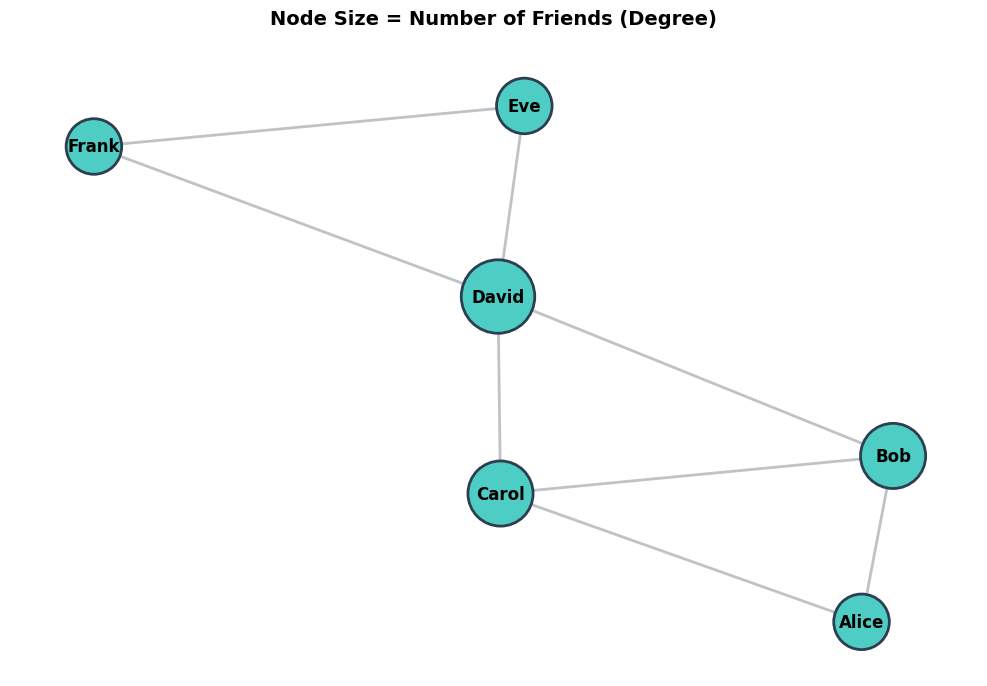

In [ ]:
# Visualize the network with node size proportional to degree
fig, ax = plt.subplots(figsize=(10, 7))

node_sizes = [degree_dict[n] * 600 + 400 for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color='#4ECDC4', node_size=node_sizes,
                       edgecolors='#2C3E50', linewidths=2, ax=ax)
nx.draw_networkx_edges(G, pos, edge_color='#BDC3C7', width=2, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold', ax=ax)

ax.set_title("Node Size = Number of Friends (Degree)",
            fontsize=14, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

### 3.2 Shortest Path: How Do Nodes Reach Each Other?

The **shortest path** between two nodes is the minimum number of steps (edges) needed to get from one to the other.

**In plain English:** Through how many people does a message need to pass to get from Alice to Frank?

Shortest path from Alice to Frank:
  Path: Alice → Bob → David → Frank
  Length: 3 steps


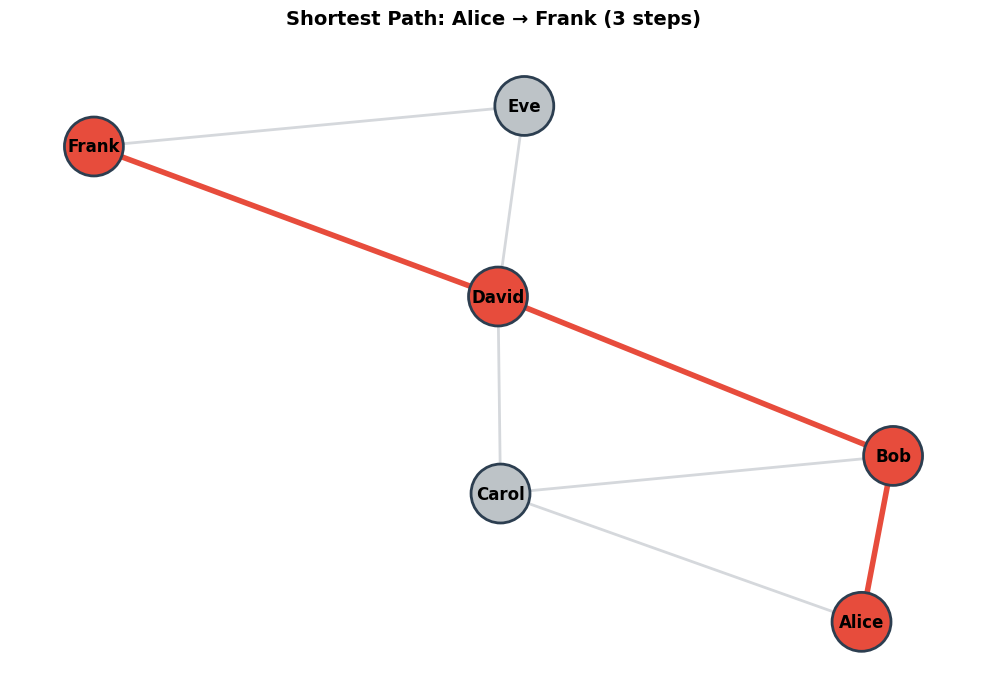

In [ ]:
# Find shortest path between Alice and Frank
source, target = "Alice", "Frank"
path = nx.shortest_path(G, source=source, target=target)
path_length = nx.shortest_path_length(G, source=source, target=target)

print(f"Shortest path from {source} to {target}:")
print(f"  Path: {' → '.join(path)}")
print(f"  Length: {path_length} steps")

# Visualize the shortest path highlighted
fig, ax = plt.subplots(figsize=(10, 7))

# Draw all edges light
nx.draw_networkx_edges(G, pos, edge_color='#D5D8DC', width=2, ax=ax)

# Highlight shortest path edges
path_edges = list(zip(path[:-1], path[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='#E74C3C', width=4, ax=ax)

# Color nodes: path nodes in red, others in grey
node_colors = ['#E74C3C' if n in path else '#BDC3C7' for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1800,
                       edgecolors='#2C3E50', linewidths=2, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold', ax=ax)

ax.set_title(f"Shortest Path: {source} → {target} ({path_length} steps)",
            fontsize=14, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

### 3.3 Centrality: Who Are the Most "Important" Nodes?

There are different ways to measure importance in a network. Let's look at three popular ones:

| Centrality | Question It Answers | Analogy |
|------------|--------------------|---------|
| **Degree centrality** | Who has the most connections? | Who has the most phone contacts? |
| **Betweenness centrality** | Who sits on the most shortest paths? | Who is the bridge between friend groups? |
| **Closeness centrality** | Who can reach everyone else fastest? | Who is geographically in the center of a city? |

In [ ]:
# Calculate all three centrality measures
degree_cent = nx.degree_centrality(G)
betweenness_cent = nx.betweenness_centrality(G)
closeness_cent = nx.closeness_centrality(G)

# Create a nice comparison table
df_centrality = pd.DataFrame({
    'Person': list(G.nodes()),
    'Degree Centrality': [round(degree_cent[n], 3) for n in G.nodes()],
    'Betweenness Centrality': [round(betweenness_cent[n], 3) for n in G.nodes()],
    'Closeness Centrality': [round(closeness_cent[n], 3) for n in G.nodes()]
}).sort_values('Betweenness Centrality', ascending=False)

print("=" * 65)
print("CENTRALITY COMPARISON")
print("=" * 65)
print(df_centrality.to_string(index=False))
print("\n💡 Higher values = more central/important by that measure")

CENTRALITY COMPARISON
Person  Degree Centrality  Betweenness Centrality  Closeness Centrality
 David                0.8                    0.60                 0.833
   Bob                0.6                    0.15                 0.714
 Carol                0.6                    0.15                 0.714
 Alice                0.4                    0.00                 0.500
   Eve                0.4                    0.00                 0.556
 Frank                0.4                    0.00                 0.556

💡 Higher values = more central/important by that measure


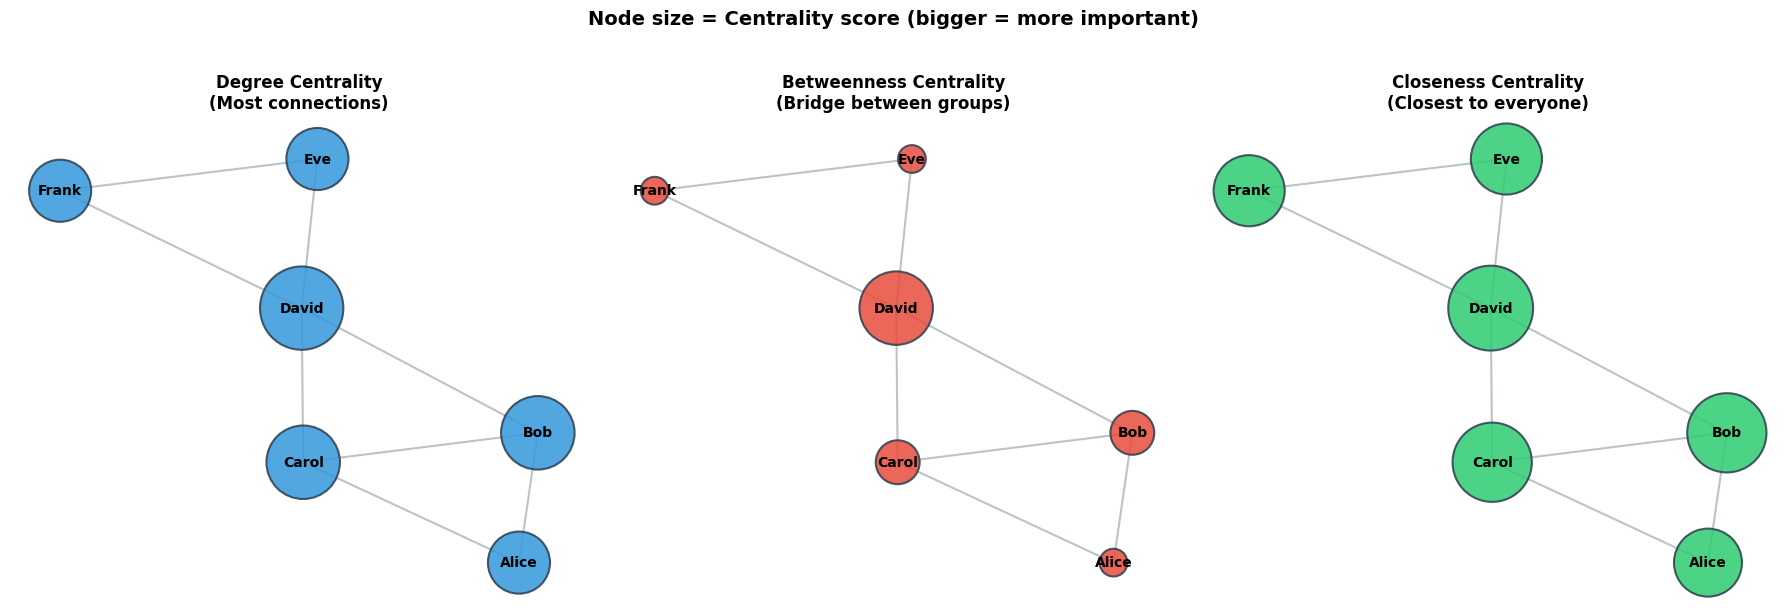

In [ ]:
# Visualize each centrality measure side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

centralities = [
    (degree_cent, "Degree Centrality\n(Most connections)", '#3498DB'),
    (betweenness_cent, "Betweenness Centrality\n(Bridge between groups)", '#E74C3C'),
    (closeness_cent, "Closeness Centrality\n(Closest to everyone)", '#2ECC71'),
]

for ax, (cent, title, color) in zip(axes, centralities):
    node_sizes = [cent[n] * 4000 + 400 for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_color=color, node_size=node_sizes,
                           edgecolors='#2C3E50', linewidths=1.5, alpha=0.85, ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color='#BDC3C7', width=1.5, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle("Node size = Centrality score (bigger = more important)",
            fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 💬 Discussion: Why Different Centralities Matter

Notice how **David** often scores high across metrics? That's because he sits at a critical junction — connecting the left cluster (Alice, Bob, Carol) with the right cluster (Eve, Frank).

In a real university network:
- **High degree centrality** = a very social student (knows many people)
- **High betweenness** = a student who bridges different social circles (e.g., connects the engineering and business students)
- **High closeness** = a student who could spread information to the whole network quickly

### 3.4 Clustering Coefficient: Do Your Friends Know Each Other?

The **clustering coefficient** measures how tightly connected a node's neighbors are to each other.

**In plain English:** If Alice is friends with Bob and Carol, are Bob and Carol also friends with each other?

In [ ]:
# Calculate clustering coefficients
clustering = nx.clustering(G)

print("=" * 50)
print("CLUSTERING COEFFICIENT")
print("(How tightly knit are each person's friends?)")
print("=" * 50)
for person, coeff in sorted(clustering.items(), key=lambda x: -x[1]):
    bar = '█' * int(coeff * 20)
    print(f"  {person:>8}: {coeff:.3f}  {bar}")

avg_clustering = nx.average_clustering(G)
print(f"\n  Network average: {avg_clustering:.3f}")
print(f"\n  💡 1.0 = all friends know each other (complete clique)")
print(f"     0.0 = none of the friends know each other")

CLUSTERING COEFFICIENT
(How tightly knit are each person's friends?)
     Alice: 1.000  ████████████████████
       Eve: 1.000  ████████████████████
     Frank: 1.000  ████████████████████
       Bob: 0.667  █████████████
     Carol: 0.667  █████████████
     David: 0.333  ██████

  Network average: 0.778

  💡 1.0 = all friends know each other (complete clique)
     0.0 = none of the friends know each other


### 3.5 Network Density: How Connected Is the Whole Network?

**Density** = the ratio of actual edges to the maximum possible edges.

- Density of **1.0** means everyone is connected to everyone (a "complete graph")
- Density of **0.0** means no connections at all

In [ ]:
n = G.number_of_nodes()
max_edges = n * (n - 1) / 2  # Maximum possible edges in an undirected graph
actual_edges = G.number_of_edges()
density = nx.density(G)

print("=" * 45)
print("NETWORK DENSITY")
print("=" * 45)
print(f"  Nodes: {n}")
print(f"  Maximum possible edges: {int(max_edges)}")
print(f"  Actual edges: {actual_edges}")
print(f"  Density: {density:.3f} ({density*100:.1f}%)")
print(f"\n  💡 About {density*100:.0f}% of all possible friendships exist.")

NETWORK DENSITY
  Nodes: 6
  Maximum possible edges: 15
  Actual edges: 8
  Density: 0.533 (53.3%)

  💡 About 53% of all possible friendships exist.


---
## 📈 Part 4: A Complete Network Summary Dashboard

Let's put it all together in one visual summary.

  Friendship Network Summary
  Nodes: 6
  Edges: 8
  Density: 0.533
  Average Clustering: 0.778
  Connected: Yes
  Diameter: 3 (longest shortest path)
  Avg. Shortest Path Length: 1.60
  Degree range: 2 – 4
  Average degree: 2.67


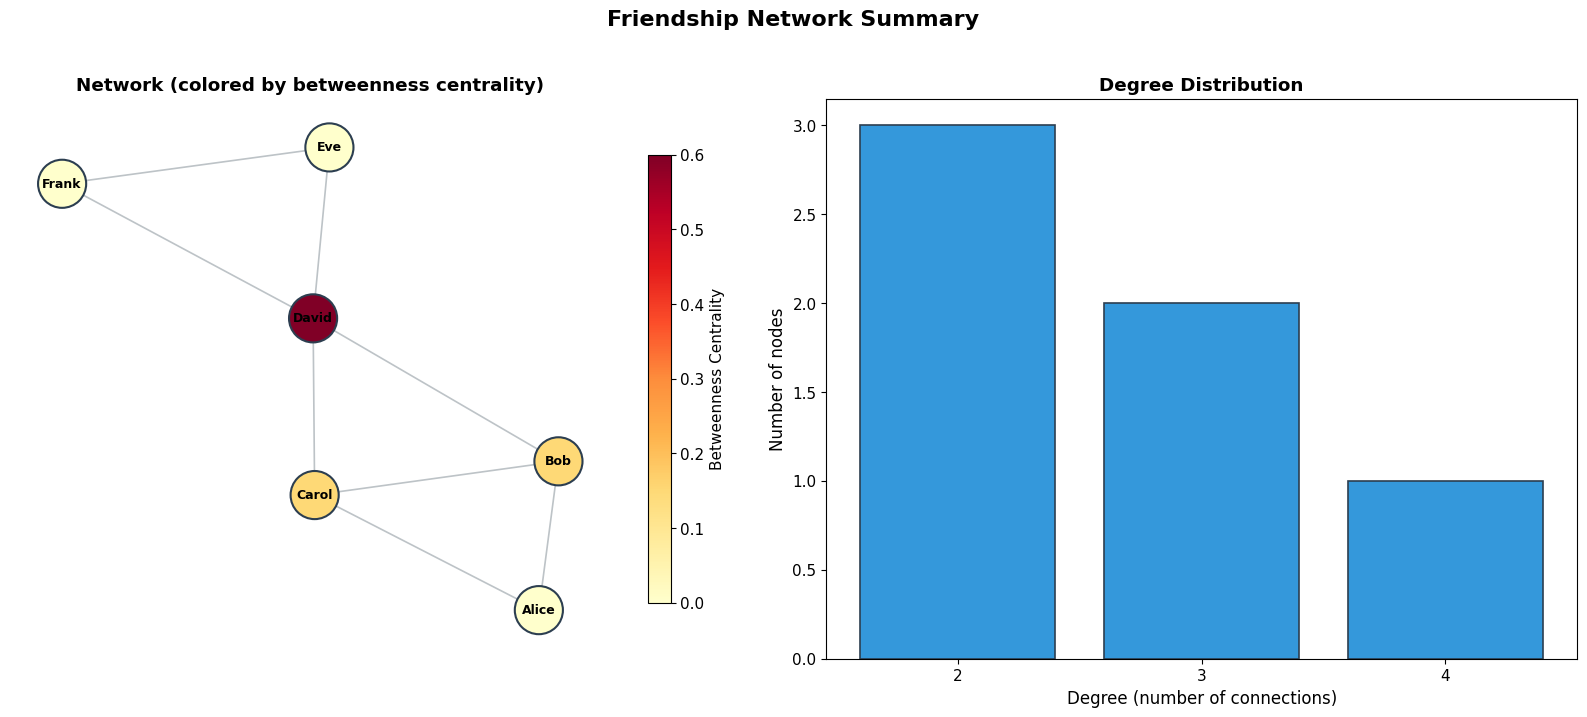

In [ ]:
def network_summary(G, title="Network Summary"):
    """Print and visualize a comprehensive summary of any network."""

    print("=" * 55)
    print(f"  {title}")
    print("=" * 55)
    print(f"  Nodes: {G.number_of_nodes()}")
    print(f"  Edges: {G.number_of_edges()}")
    print(f"  Density: {nx.density(G):.3f}")
    print(f"  Average Clustering: {nx.average_clustering(G):.3f}")

    if nx.is_connected(G):
        print(f"  Connected: Yes")
        print(f"  Diameter: {nx.diameter(G)} (longest shortest path)")
        print(f"  Avg. Shortest Path Length: {nx.average_shortest_path_length(G):.2f}")
    else:
        components = list(nx.connected_components(G))
        print(f"  Connected: No ({len(components)} components)")

    # Degree distribution
    degrees = [d for _, d in G.degree()]
    print(f"  Degree range: {min(degrees)} – {max(degrees)}")
    print(f"  Average degree: {np.mean(degrees):.2f}")
    print("=" * 55)

    # --- Visualization ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Left: Network visualization colored by betweenness centrality
    bc = nx.betweenness_centrality(G)
    bc_values = [bc[n] for n in G.nodes()]
    pos = nx.spring_layout(G, seed=42)

    nodes = nx.draw_networkx_nodes(G, pos, node_color=bc_values, cmap=plt.cm.YlOrRd,
                                   node_size=1200, edgecolors='#2C3E50', linewidths=1.5,
                                   ax=axes[0])
    nx.draw_networkx_edges(G, pos, edge_color='#BDC3C7', width=1.2, ax=axes[0])
    if G.number_of_nodes() <= 20:
        nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', ax=axes[0])
    plt.colorbar(nodes, ax=axes[0], label='Betweenness Centrality', shrink=0.8)
    axes[0].set_title("Network (colored by betweenness centrality)", fontweight='bold')
    axes[0].axis('off')

    # Right: Degree distribution histogram
    degree_counts = Counter(degrees)
    x = sorted(degree_counts.keys())
    y = [degree_counts[k] for k in x]
    axes[1].bar(x, y, color='#3498DB', edgecolor='#2C3E50', linewidth=1.2)
    axes[1].set_xlabel('Degree (number of connections)', fontsize=12)
    axes[1].set_ylabel('Number of nodes', fontsize=12)
    axes[1].set_title('Degree Distribution', fontweight='bold')
    axes[1].set_xticks(x)

    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Run it on our friendship network!
network_summary(G, "Friendship Network Summary")

---
## 🌍 Part 5: Famous Network Models

Researchers have discovered that real-world networks tend to follow certain patterns. Let's look at three famous models and see how they differ.

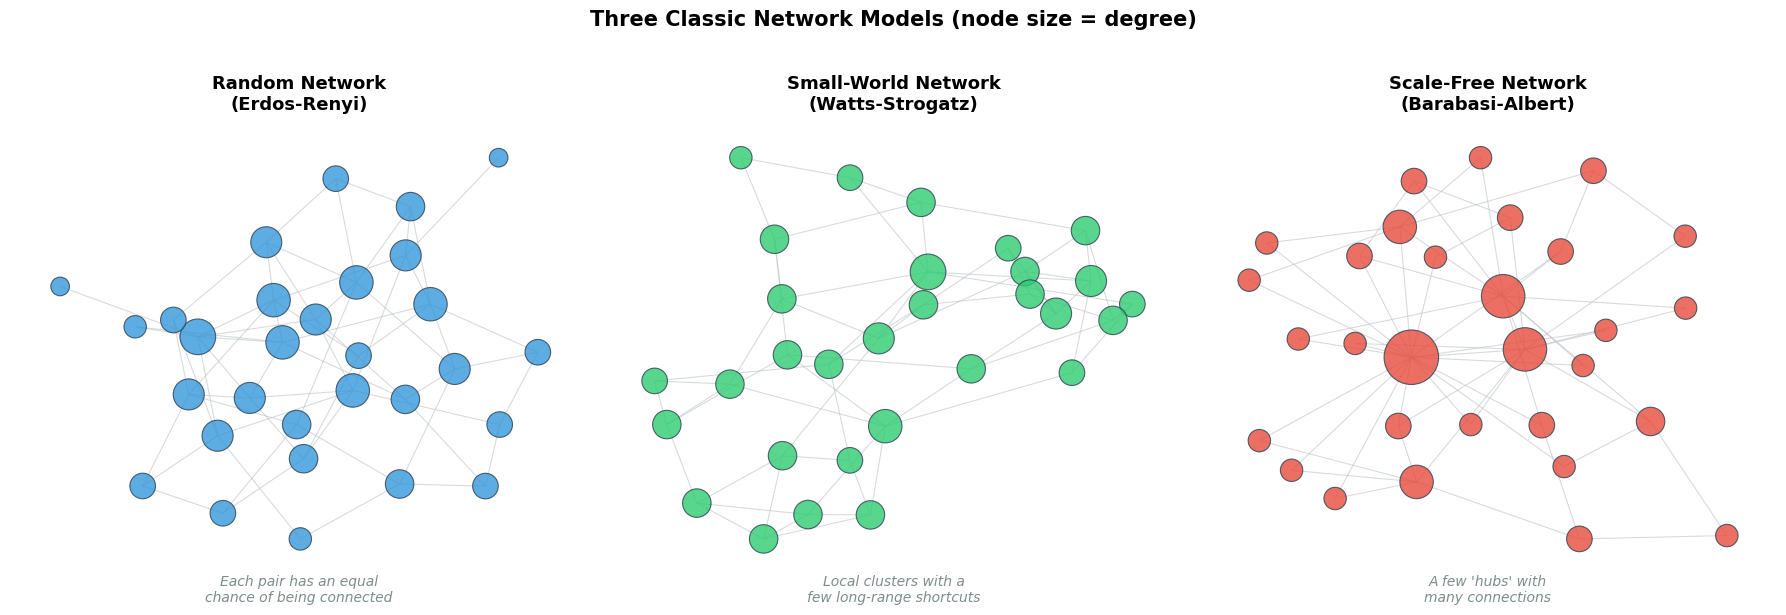

Metric                             Random  Small-World   Scale-Free
-----------------------------------------------------------------
Nodes                                  30           30           30
Edges                                  61           60           56
Avg. Clustering                     0.134        0.197        0.300
Density                             0.140        0.138        0.129


In [ ]:
# Generate three classic network models
np.random.seed(42)
n = 30  # 30 nodes each

# 1. Random (Erdos-Renyi): each pair connected with probability p
G_random = nx.erdos_renyi_graph(n, 0.15, seed=42)

# 2. Small-World (Watts-Strogatz): regular ring + some random shortcuts
G_smallworld = nx.watts_strogatz_graph(n, 4, 0.3, seed=42)

# 3. Scale-Free (Barabasi-Albert): new nodes prefer to connect to popular ones
G_scalefree = nx.barabasi_albert_graph(n, 2, seed=42)

# Visualize side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = [
    (G_random, "Random Network\n(Erdos-Renyi)", '#3498DB',
     "Each pair has an equal\nchance of being connected"),
    (G_smallworld, "Small-World Network\n(Watts-Strogatz)", '#2ECC71',
     "Local clusters with a\nfew long-range shortcuts"),
    (G_scalefree, "Scale-Free Network\n(Barabasi-Albert)", '#E74C3C',
     "A few 'hubs' with\nmany connections"),
]

for ax, (g, title, color, desc) in zip(axes, models):
    pos_m = nx.spring_layout(g, seed=42)
    degrees_m = dict(g.degree())
    node_sizes = [degrees_m[n_id] * 80 + 100 for n_id in g.nodes()]

    nx.draw_networkx_nodes(g, pos_m, node_color=color, node_size=node_sizes,
                           edgecolors='#2C3E50', linewidths=0.8, alpha=0.8, ax=ax)
    nx.draw_networkx_edges(g, pos_m, edge_color='#BDC3C7', width=0.8, alpha=0.6, ax=ax)

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.text(0.5, -0.05, desc, transform=ax.transAxes, ha='center',
            fontsize=10, style='italic', color='#7F8C8D')
    ax.axis('off')

plt.suptitle("Three Classic Network Models (node size = degree)",
            fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Compare metrics
print(f"{'Metric':<30} {'Random':>10} {'Small-World':>12} {'Scale-Free':>12}")
print("-" * 65)
print(f"{'Nodes':<30} {G_random.number_of_nodes():>10} {G_smallworld.number_of_nodes():>12} {G_scalefree.number_of_nodes():>12}")
print(f"{'Edges':<30} {G_random.number_of_edges():>10} {G_smallworld.number_of_edges():>12} {G_scalefree.number_of_edges():>12}")
print(f"{'Avg. Clustering':<30} {nx.average_clustering(G_random):>10.3f} {nx.average_clustering(G_smallworld):>12.3f} {nx.average_clustering(G_scalefree):>12.3f}")
print(f"{'Density':<30} {nx.density(G_random):>10.3f} {nx.density(G_smallworld):>12.3f} {nx.density(G_scalefree):>12.3f}")

### 💬 Key Takeaways on Network Models

| Model | Real-World Example | Key Feature |
|-------|--------------------|-------------|
| **Random** | Ad-hoc wireless sensor networks | No special structure; connections are random |
| **Small-World** | Your social circle, neural networks | High clustering + short paths ("six degrees of separation") |
| **Scale-Free** | The Internet, citation networks, airports | A few super-connected hubs dominate |

---
## 🏫 Part 6: A Practical Example — University Course Co-enrollment Network

Let's simulate a network that's closer to an educational context: students connected by shared courses.

In [ ]:
# Simulate student enrollment data
random.seed(42)

courses = ["Stats 101", "Data Science", "Linear Algebra", "Intro to CS",
           "Machine Learning", "Calculus II", "Research Methods"]

students = [f"Student_{i+1:02d}" for i in range(20)]

# Each student takes 2-4 courses
enrollment = {}
for s in students:
    n_courses = random.randint(2, 4)
    enrollment[s] = random.sample(courses, n_courses)

# Print a sample
print("Sample Enrollment:")
for s in students[:5]:
    print(f"  {s}: {', '.join(enrollment[s])}")
print(f"  ... ({len(students)} students total)")

Sample Enrollment:
  Student_01: Stats 101, Research Methods, Linear Algebra, Data Science
  Student_02: Data Science, Calculus II
  Student_03: Calculus II, Research Methods
  Student_04: Stats 101, Machine Learning, Intro to CS, Research Methods
  Student_05: Stats 101, Data Science
  ... (20 students total)


Co-enrollment network:
  Students: 20
  Connections (shared courses): 147
  Density: 0.774


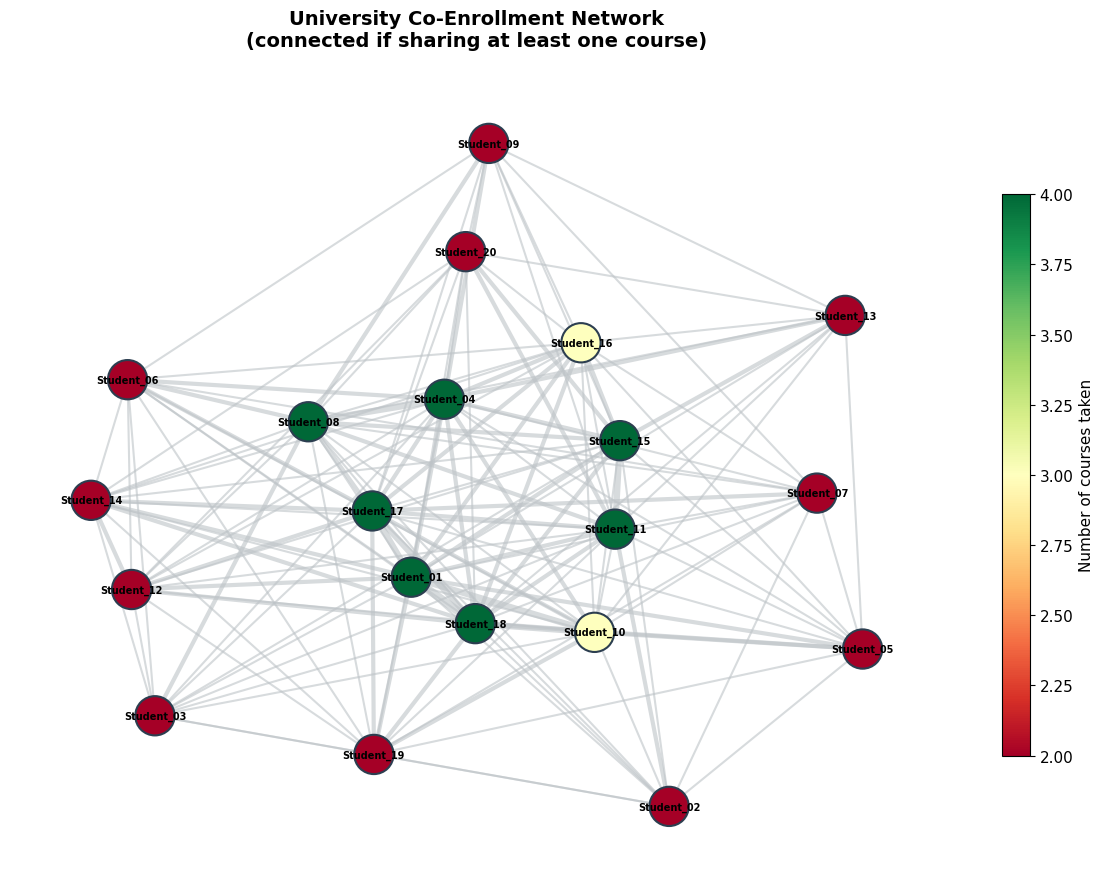

In [ ]:
# Build the co-enrollment network
# Two students are connected if they share at least one course
G_uni = nx.Graph()
G_uni.add_nodes_from(students)

for i, s1 in enumerate(students):
    for s2 in students[i+1:]:
        shared = set(enrollment[s1]) & set(enrollment[s2])
        if shared:
            G_uni.add_edge(s1, s2, weight=len(shared), courses=list(shared))

print(f"Co-enrollment network:")
print(f"  Students: {G_uni.number_of_nodes()}")
print(f"  Connections (shared courses): {G_uni.number_of_edges()}")
print(f"  Density: {nx.density(G_uni):.3f}")

# Visualize
fig, ax = plt.subplots(figsize=(12, 9))
pos_uni = nx.spring_layout(G_uni, seed=42, k=0.5)

# Color by number of courses taken
n_courses_per_student = {s: len(enrollment[s]) for s in students}
node_colors = [n_courses_per_student[s] for s in G_uni.nodes()]

# Edge width by number of shared courses
edge_widths = [G_uni[u][v]['weight'] * 1.5 for u, v in G_uni.edges()]

nodes = nx.draw_networkx_nodes(G_uni, pos_uni, node_color=node_colors, cmap=plt.cm.RdYlGn,
                                node_size=800, edgecolors='#2C3E50', linewidths=1.5, ax=ax)
nx.draw_networkx_edges(G_uni, pos_uni, edge_color='#BDC3C7', width=edge_widths, alpha=0.6, ax=ax)
nx.draw_networkx_labels(G_uni, pos_uni, font_size=7, font_weight='bold', ax=ax)

plt.colorbar(nodes, ax=ax, label='Number of courses taken', shrink=0.7)
ax.set_title("University Co-Enrollment Network\n(connected if sharing at least one course)",
            fontsize=14, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Who are the most central students?
bc_uni = nx.betweenness_centrality(G_uni)
dc_uni = nx.degree_centrality(G_uni)

df_uni = pd.DataFrame({
    'Student': list(G_uni.nodes()),
    'Courses Taken': [len(enrollment[s]) for s in G_uni.nodes()],
    'Connections': [G_uni.degree(s) for s in G_uni.nodes()],
    'Degree Centrality': [round(dc_uni[s], 3) for s in G_uni.nodes()],
    'Betweenness Centrality': [round(bc_uni[s], 3) for s in G_uni.nodes()],
}).sort_values('Betweenness Centrality', ascending=False)

print("Top 5 Most Central Students:")
print(df_uni.head(5).to_string(index=False))

Top 5 Most Central Students:
   Student  Courses Taken  Connections  Degree Centrality  Betweenness Centrality
Student_11              4           18              0.947                   0.025
Student_08              4           18              0.947                   0.024
Student_04              4           18              0.947                   0.023
Student_17              4           18              0.947                   0.023
Student_01              4           18              0.947                   0.022


---
## 🏋️ Part 7: Exercises

Now it's your turn! Complete the exercises below to practice what you've learned.

---

### Exercise 1: Build Your Own Network (Easy)

Create a network of **at least 5 nodes** representing something you're interested in (e.g., your favorite movies connected by shared actors, cities connected by highways, etc.).

**Tasks:**
1. Create the network using `nx.Graph()`
2. Add nodes and edges
3. Visualize it
4. Print the number of nodes, edges, and density

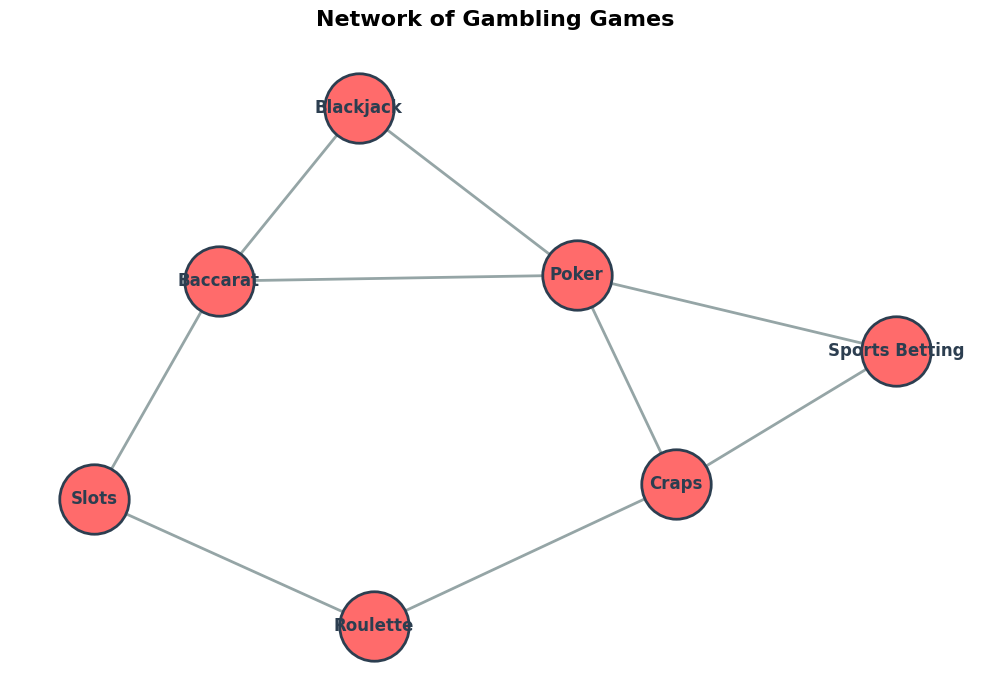


NETWORK STATISTICS
Nodes: 7
Edges: 9
Density: 0.429


In [1]:
# ============================================
# EXERCISE 1: Build Your Own Network (Solution)
# ============================================

import networkx as nx
import matplotlib.pyplot as plt

# Step 1: Create a graph representing gambling games
my_graph = nx.Graph()

# Step 2: Add nodes (gambling games)
games = ["Poker", "Blackjack", "Roulette", "Sports Betting", "Slots", "Craps", "Baccarat"]
my_graph.add_nodes_from(games)

# Step 3: Add edges (connections/overlap)
connections = [
    ("Poker", "Blackjack"),      # Card games, casino table games
    ("Poker", "Craps"),         # Casino table games, strategy involved
    ("Blackjack", "Baccarat"),   # Card games, casino table games
    ("Roulette", "Craps"),      # Casino table games, pure chance
    ("Roulette", "Slots"),       # Casino games, pure chance
    ("Sports Betting", "Poker"), # Skill/knowledge involved
    ("Sports Betting", "Craps"), # Popular in Las Vegas
    ("Slots", "Baccarat"),       # Casino games, pure chance
    ("Poker", "Baccarat")
]
my_graph.add_edges_from(connections)

# Step 4: Visualize the network
fig, ax = plt.subplots(figsize=(10, 7))

# Position nodes nicely
pos_my_graph = nx.spring_layout(my_graph, seed=100)

nx.draw_networkx_nodes(my_graph, pos_my_graph, node_color='#FF6B6B', node_size=2500,
                       edgecolors='#2C3E50', linewidths=2, ax=ax)
nx.draw_networkx_edges(my_graph, pos_my_graph, edge_color='#95A5A6', width=2, ax=ax)
nx.draw_networkx_labels(my_graph, pos_my_graph, font_size=12, font_weight='bold',
                        font_color='#2C3E50', ax=ax)

ax.set_title("Network of Gambling Games", fontsize=16, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

# Step 5: Print stats
print(f"\n{'=' * 30}")
print(f"NETWORK STATISTICS")
print(f"{'=' * 30}")
print(f"Nodes: {my_graph.number_of_nodes()}")
print(f"Edges: {my_graph.number_of_edges()}")
print(f"Density: {nx.density(my_graph):.3f}")
print(f"{'=' * 30}")

---
### Exercise 2: Find the Key Player (Medium)

Use the `G_uni` (university co-enrollment) network from Part 6.

**Tasks:**
1. Find the student with the **highest closeness centrality**
2. Find all the courses that student is enrolled in
3. Find the **shortest path** between `Student_01` and `Student_20`
4. What is the **diameter** of the network? (The longest shortest path)

In [4]:
# ============================================
# EXERCISE 2: Find the Key Player (Solution)
# ============================================

# --- Prepending definitions from Part 6 to ensure G_uni and enrollment are defined ---
import random
import networkx as nx

# Simulate student enrollment data (from cell ZRi_m1hpxio3)
random.seed(42)

courses = ["Stats 101", "Data Science", "Linear Algebra", "Intro to CS",
           "Machine Learning", "Calculus II", "Research Methods"]

students = [f"Student_{i+1:02d}" for i in range(20)]

# Each student takes 2-4 courses
enrollment = {}
for s in students:
    n_courses = random.randint(2, 4)
    enrollment[s] = random.sample(courses, n_courses)

# Build the co-enrollment network (from cell sGzV4KKXxio3)
G_uni = nx.Graph()
G_uni.add_nodes_from(students)

for i, s1 in enumerate(students):
    for s2 in students[i+1:]:
        shared = set(enrollment[s1]) & set(enrollment[s2])
        if shared:
            G_uni.add_edge(s1, s2, weight=len(shared), courses=list(shared))
# ----------------------------------------------------------------------------------


# Task 1: Highest closeness centrality
cc_uni = nx.closeness_centrality(G_uni)
highest_cc_student = max(cc_uni, key=cc_uni.get)
print(f"Student with the highest closeness centrality: {highest_cc_student} (Score: {cc_uni[highest_cc_student]:.3f})")

# Task 2: What courses does that student take?
if highest_cc_student in enrollment:
    print(f"{highest_cc_student} is enrolled in: {', '.join(enrollment[highest_cc_student])}")
else:
    print(f"Enrollment information not found for {highest_cc_student}")

# Task 3: Shortest path from Student_01 to Student_20
source_student = "Student_01"
target_student = "Student_20"

if nx.has_path(G_uni, source_student, target_student):
    path_s01_s20 = nx.shortest_path(G_uni, source=source_student, target=target_student)
    path_length_s01_s20 = nx.shortest_path_length(G_uni, source=source_student, target=target_student)
    print(f"\nShortest path from {source_student} to {target_student}:")
    print(f"  Path: {' -> '.join(path_s01_s20)}")
    print(f"  Length: {path_length_s01_s20} steps")
else:
    print(f"\nNo path found between {source_student} and {target_student}.")

# Task 4: Diameter of the network
if nx.is_connected(G_uni):
    diameter_uni = nx.diameter(G_uni)
    print(f"\nDiameter of the G_uni network: {diameter_uni}")
else:
    print("\nG_uni is not connected, so it does not have a diameter.")

Student with the highest closeness centrality: Student_01 (Score: 0.950)
Student_01 is enrolled in: Stats 101, Research Methods, Linear Algebra, Data Science

Shortest path from Student_01 to Student_20:
  Path: Student_01 -> Student_20
  Length: 1 steps

Diameter of the G_uni network: 2


---
### Exercise 3: Compare Random vs. Real (Medium–Hard)

Generate a random network with the **same number of nodes and edges** as `G_uni`, then compare their properties.

**Tasks:**
1. Create a random graph using `nx.gnm_random_graph(n, m)` with the same n and m as `G_uni`
2. Compare: density, average clustering, average shortest path length
3. Use the `network_summary()` function from Part 4 on both networks
4. Discuss: Does the co-enrollment network look more like a random network or a small-world network?


NETWORK METRICS COMPARISON: Co-enrollment vs. Random
Metric                             Co-enrollment (G_uni)      Random (G_rand)
--------------------------------------------------------------------------------
Density                                            0.774                0.774
Average Clustering Coefficient                     0.831                0.773
Average Shortest Path Length                       1.226                1.226
  Co-enrollment Network (G_uni)
  Nodes: 20
  Edges: 147
  Density: 0.774
  Average Clustering: 0.831
  Connected: Yes
  Diameter: 2 (longest shortest path)
  Avg. Shortest Path Length: 1.23
  Degree range: 10 – 18
  Average degree: 14.70


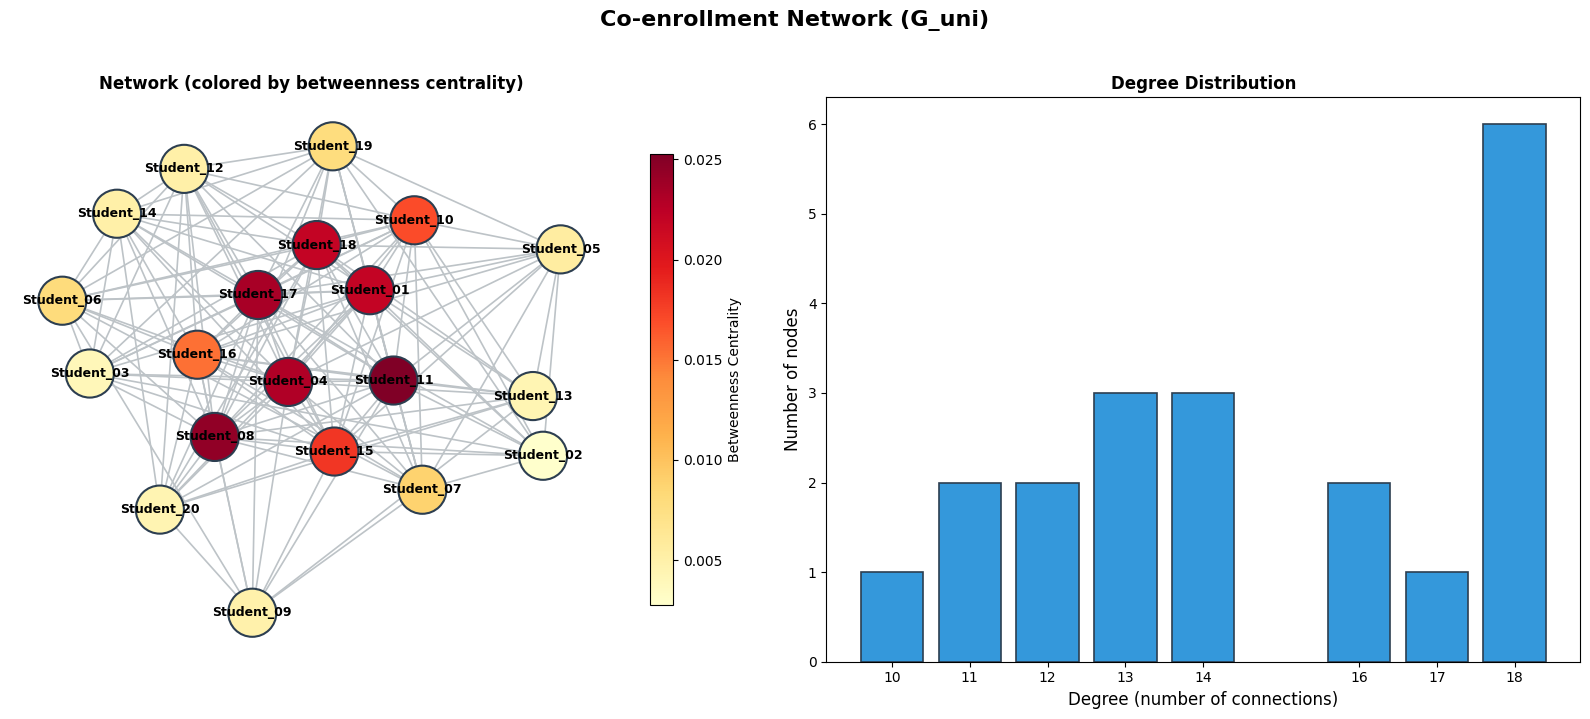

  Random Network (G_rand)
  Nodes: 20
  Edges: 147
  Density: 0.774
  Average Clustering: 0.773
  Connected: Yes
  Diameter: 2 (longest shortest path)
  Avg. Shortest Path Length: 1.23
  Degree range: 12 – 18
  Average degree: 14.70


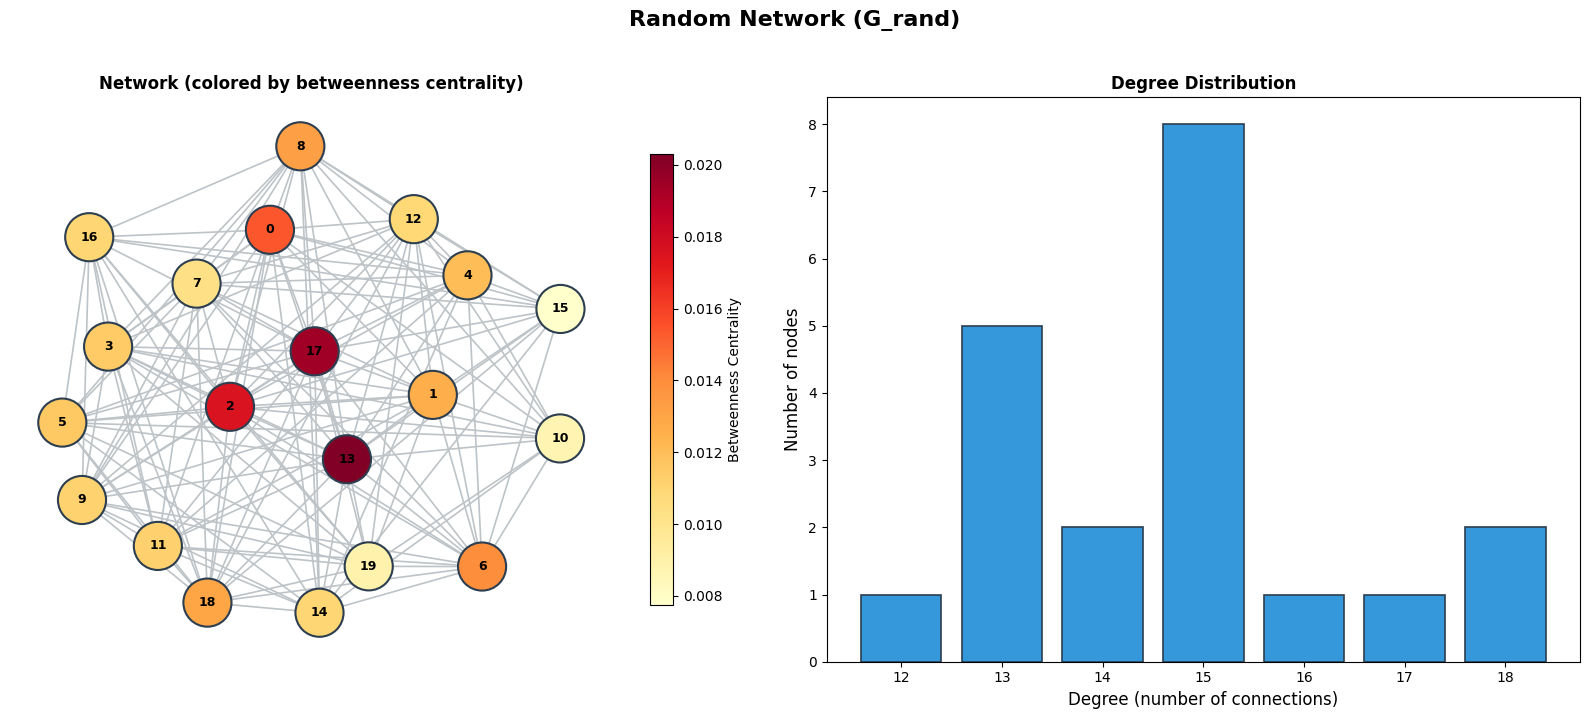

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# --- Prepending definition of network_summary from Part 4 ---
def network_summary(G, title="Network Summary"):
    """Print and visualize a comprehensive summary of any network."""

    print("=" * 55)
    print(f"  {title}")
    print("=" * 55)
    print(f"  Nodes: {G.number_of_nodes()}")
    print(f"  Edges: {G.number_of_edges()}")
    print(f"  Density: {nx.density(G):.3f}")
    print(f"  Average Clustering: {nx.average_clustering(G):.3f}")

    if nx.is_connected(G):
        print(f"  Connected: Yes")
        print(f"  Diameter: {nx.diameter(G)} (longest shortest path)")
        print(f"  Avg. Shortest Path Length: {nx.average_shortest_path_length(G):.2f}")
    else:
        components = list(nx.connected_components(G))
        print(f"  Connected: No ({len(components)} components)")

    # Degree distribution
    degrees = [d for _, d in G.degree()]
    print(f"  Degree range: {min(degrees)} – {max(degrees)}")
    print(f"  Average degree: {np.mean(degrees):.2f}")
    print("=" * 55)

    # --- Visualization ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Left: Network visualization colored by betweenness centrality
    bc = nx.betweenness_centrality(G)
    bc_values = [bc[n] for n in G.nodes()]
    pos = nx.spring_layout(G, seed=42)

    nodes = nx.draw_networkx_nodes(G, pos, node_color=bc_values, cmap=plt.cm.YlOrRd,
                                   node_size=1200, edgecolors='#2C3E50', linewidths=1.5,
                                   ax=axes[0])
    nx.draw_networkx_edges(G, pos, edge_color='#BDC3C7', width=1.2, ax=axes[0])
    if G.number_of_nodes() <= 20:
        nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', ax=axes[0])
    plt.colorbar(nodes, ax=axes[0], label='Betweenness Centrality', shrink=0.8)
    axes[0].set_title("Network (colored by betweenness centrality)", fontweight='bold')
    axes[0].axis('off')

    # Right: Degree distribution histogram
    degree_counts = Counter(degrees)
    x = sorted(degree_counts.keys())
    y = [degree_counts[k] for k in x]
    axes[1].bar(x, y, color='#3498DB', edgecolor='#2C3E50', linewidth=1.2)
    axes[1].set_xlabel('Degree (number of connections)', fontsize=12)
    axes[1].set_ylabel('Number of nodes', fontsize=12)
    axes[1].set_title('Degree Distribution', fontweight='bold')
    axes[1].set_xticks(x)

    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
# ---------------------------------------------------------------

# ============================================
# EXERCISE 3: Compare Random vs. Real
# ============================================

# Task 1: Generate random graph with same n and m
n = G_uni.number_of_nodes()
m = G_uni.number_of_edges()
G_rand = nx.gnm_random_graph(n, m, seed=42)

# Task 2: Compare metrics
print("\n" + "=" * 60)
print("NETWORK METRICS COMPARISON: Co-enrollment vs. Random")
print("=" * 60)
print(f"{'Metric':<30} {'Co-enrollment (G_uni)':>25} {'Random (G_rand)':>20}")
print("-" * 80)

# Density
density_uni = nx.density(G_uni)
density_rand = nx.density(G_rand)
print(f"{'Density':<30} {density_uni:>25.3f} {density_rand:>20.3f}")

# Average Clustering
avg_clustering_uni = nx.average_clustering(G_uni)
avg_clustering_rand = nx.average_clustering(G_rand)
print(f"{'Average Clustering Coefficient':<30} {avg_clustering_uni:>25.3f} {avg_clustering_rand:>20.3f}")

# Average Shortest Path Length (check connectivity first)
avg_spl_uni = 'N/A'
if nx.is_connected(G_uni):
    avg_spl_uni = nx.average_shortest_path_length(G_uni)

avg_spl_rand = 'N/A'
if nx.is_connected(G_rand):
    avg_spl_rand = nx.average_shortest_path_length(G_rand)

print(f"{'Average Shortest Path Length':<30} {avg_spl_uni:>25.3f} {avg_spl_rand:>20.3f}")
print("=" * 80)


# Task 3: Use network_summary() on both
network_summary(G_uni, "Co-enrollment Network (G_uni)")
network_summary(G_rand, "Random Network (G_rand)")

# Task 4: Write your discussion here
# Based on the comparison, the co-enrollment network (G_uni) exhibits a significantly higher
# average clustering coefficient than the random network (G_rand), while maintaining a relatively
# small average shortest path length. This combination of high clustering and short path lengths
# is a hallmark characteristic of 'Small-World' networks, as described by Watts and Strogatz.
# Random networks typically have low clustering coefficients for a given density.
# Therefore, the co-enrollment network looks more like a small-world network than a purely random one.


---
### Exercise 4: Community Detection (Hard)

Communities are groups of nodes that are more densely connected to each other than to the rest of the network — like friend cliques.

**Tasks:**
1. Use the Louvain community detection algorithm on `G_uni`
2. Color the nodes by their community
3. How many communities were found?
4. Do the communities correspond to shared courses?

/tmp/ipykernel_11887/647640624.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', num_communities)


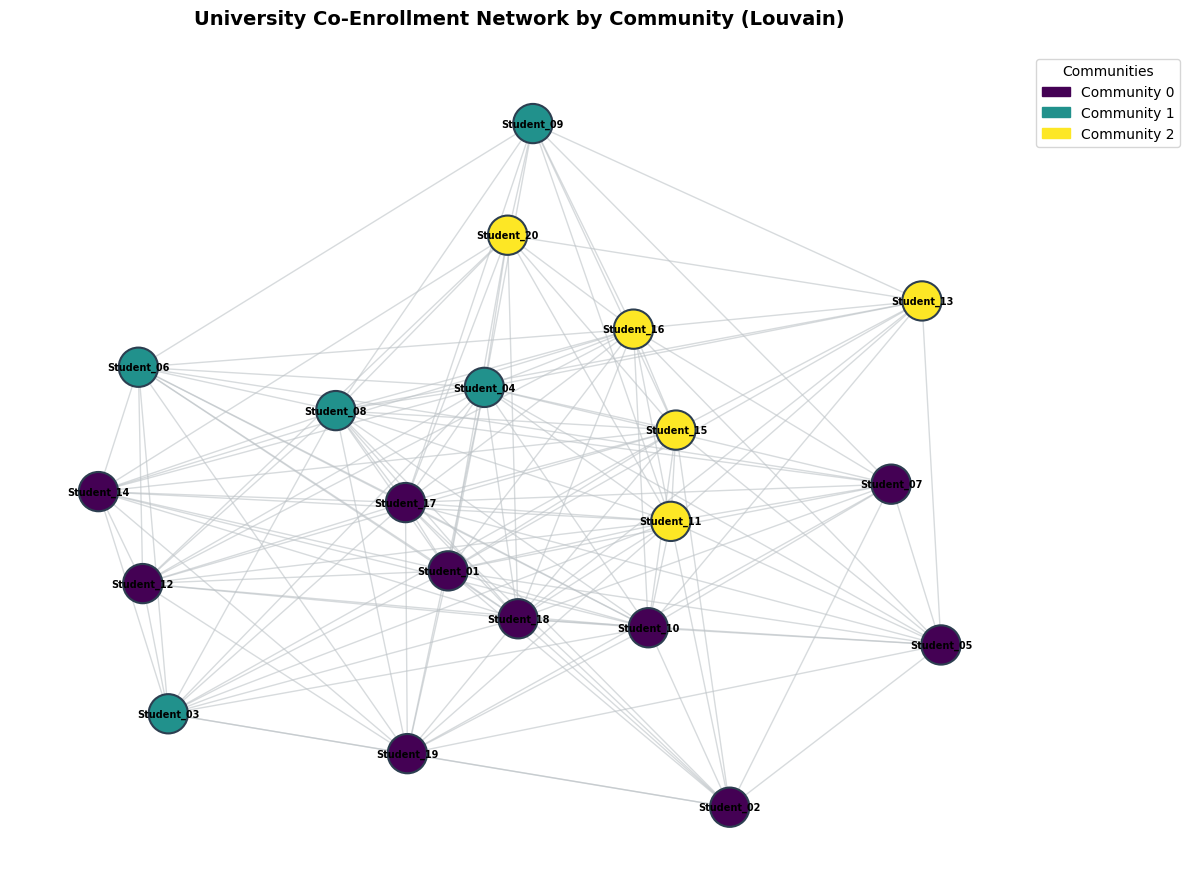


Number of communities found: 3

Top courses within each community:
  Community 0: 
    - Data Science (count: 8)
    - Research Methods (count: 7)
    - Linear Algebra (count: 5)
  Community 1: 
    - Research Methods (count: 4)
    - Machine Learning (count: 4)
    - Intro to CS (count: 3)
  Community 2: 
    - Intro to CS (count: 4)
    - Linear Algebra (count: 4)
    - Stats 101 (count: 3)

Discussion for Task 4: We can observe if certain courses are highly prevalent within specific communities. A strong correlation would imply that students taking similar courses tend to form a community, reflecting shared academic interests as a driving force for network connections.


In [10]:
# ============================================
# EXERCISE 4: Community Detection
# ============================================

# Ensure G_uni and enrollment are defined
# (Assuming previous cells with G_uni and enrollment definitions have been run)
import networkx as nx
import matplotlib.pyplot as plt
import random
from collections import Counter
import matplotlib.patches as mpatches # Added this import
import sys # Import sys for module reloading

# Simulate student enrollment data (copied from ZRi_m1hpxio3 if not already run)
# This block is for ensuring G_uni is defined correctly if the notebook is run out of order
# It can be removed if the preceding cells are guaranteed to be executed.
if 'G_uni' not in globals() or 'enrollment' not in globals():
    random.seed(42)
    courses = ["Stats 101", "Data Science", "Linear Algebra", "Intro to CS",
               "Machine Learning", "Calculus II", "Research Methods"]
    students = [f"Student_{i+1:02d}" for i in range(20)]
    enrollment = {}
    for s in students:
        n_courses = random.randint(2, 4)
        enrollment[s] = random.sample(courses, n_courses)
    G_uni = nx.Graph()
    G_uni.add_nodes_from(students)
    for i, s1 in enumerate(students):
        for s2 in students[i+1:]:
            shared = set(enrollment[s1]) & set(enrollment[s2])
            if shared:
                G_uni.add_edge(s1, s2, weight=len(shared), courses=list(shared))

# Task 1 & 2: Detect communities and visualize
# Force a clean install of python-louvain to resolve potential conflicts
!pip uninstall python-louvain --yes --quiet
!pip install python-louvain --quiet

# Try to force reload the 'community' module if it was previously loaded
if 'community' in sys.modules:
    del sys.modules['community']

import community as community_louvain

# Apply Louvain algorithm
partition = community_louvain.best_partition(G_uni)

# Get node colors based on community assignment
node_colors = [partition[node] for node in G_uni.nodes()]

# Get unique community IDs for mapping colors
unique_communities = list(set(node_colors))
num_communities = len(unique_communities)

# Create a color map for visualization
cmap = plt.cm.get_cmap('viridis', num_communities)
color_map = {comm_id: cmap(idx) for idx, comm_id in enumerate(unique_communities)}
node_color_list = [color_map[partition[node]] for node in G_uni.nodes()]

# Visualize the network with community colors
fig, ax = plt.subplots(figsize=(12, 9))
pos_uni = nx.spring_layout(G_uni, seed=42, k=0.5)

nodes = nx.draw_networkx_nodes(G_uni, pos_uni, node_color=node_color_list, node_size=800,
                               edgecolors='#2C3E50', linewidths=1.5, ax=ax)
nx.draw_networkx_edges(G_uni, pos_uni, edge_color='#BDC3C7', width=1, alpha=0.6, ax=ax)
nx.draw_networkx_labels(G_uni, pos_uni, font_size=7, font_weight='bold', ax=ax)

# Create a legend for communities
legend_handles = []
for comm_id in unique_communities:
    patch = mpatches.Patch(color=color_map[comm_id], label=f'Community {comm_id}')
    legend_handles.append(patch)
ax.legend(handles=legend_handles, title='Communities', loc='upper left', bbox_to_anchor=(1, 1))

ax.set_title("University Co-Enrollment Network by Community (Louvain)",
            fontsize=14, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

# Task 3: How many communities?
print(f"\nNumber of communities found: {num_communities}")

# Task 4: Do the communities correspond to shared courses?
print("\nTop courses within each community:")
community_courses = {comm_id: [] for comm_id in unique_communities}

for student, comm_id in partition.items():
    if student in enrollment:
        community_courses[comm_id].extend(enrollment[student])

for comm_id, courses_list in community_courses.items():
    if courses_list:
        course_counts = Counter(courses_list)
        # Get the top 3 most common courses in this community
        top_courses = course_counts.most_common(3)
        print(f"  Community {comm_id}: ")
        for course, count in top_courses:
            print(f"    - {course} (count: {count})")
    else:
        print(f"  Community {comm_id}: No course data available.")

print("\nDiscussion for Task 4: We can observe if certain courses are highly prevalent within specific communities. A strong correlation would imply that students taking similar courses tend to form a community, reflecting shared academic interests as a driving force for network connections.")

---
### Exercise 5: Network Robustness (Hard)

What happens to a network when you remove important nodes? This simulates things like: what happens to the Internet if a major hub goes down?

**Tasks:**
1. Start with the scale-free network `G_scalefree` from Part 5
2. Simulate **random node removal**: remove 5 random nodes one at a time, each time recording the size of the largest connected component
3. Simulate **targeted attack**: remove the top 5 highest-degree nodes one at a time, recording the same metric
4. Plot both curves on the same chart. What do you notice?

Simulating Random Node Removal...
  Step 1 (Removed: 12, Random): Largest component size = 29
  Step 2 (Removed: 23, Random): Largest component size = 28
  Step 3 (Removed: 13, Random): Largest component size = 27
  Step 4 (Removed: 9, Random): Largest component size = 26
  Step 5 (Removed: 19, Random): Largest component size = 25

Simulating Targeted Attack (Highest Degree Removal)...
  Step 1 (Removed: 0, Targeted): Largest component size = 29
  Step 2 (Removed: 1, Targeted): Largest component size = 25
  Step 3 (Removed: 4, Targeted): Largest component size = 10
  Step 4 (Removed: 5, Targeted): Largest component size = 10
  Step 5 (Removed: 8, Targeted): Largest component size = 5


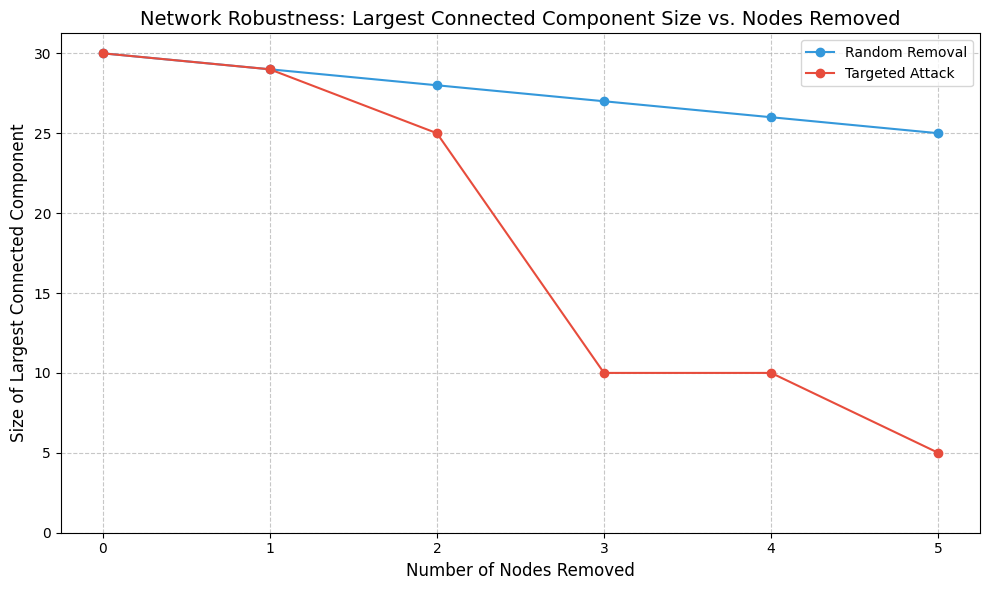


DISCUSSION: What do you notice?
The plot clearly illustrates the difference in network robustness between random node failures and targeted attacks, especially in a scale-free network. 

1.  **Targeted Attack's Greater Impact**: Removing high-degree nodes (hubs) in a targeted attack causes a much more rapid and severe fragmentation of the network. The size of the largest connected component drops significantly faster compared to random removal.

2.  **Random Removal's Resilience**: The network is more resilient to random failures. Removing a random node is less likely to disconnect major parts of the network, so the largest connected component shrinks more gradually.

3.  **Scale-Free Network Characteristic**: This behavior is characteristic of scale-free networks, which have a few highly connected 'hub' nodes and many sparsely connected nodes. These hubs are critical for maintaining the network's connectivity. Their removal has a disproportionately large impact.

In real-world scenar

In [11]:
# ============================================
# EXERCISE 5: Network Robustness
# ============================================

# Hint: To find the largest connected component size:
# max(len(c) for c in nx.connected_components(G_copy))
#
# To remove a node: G_copy.remove_node(node)
# Make copies so you don't modify the original: G_copy = G_scalefree.copy()

import random
import matplotlib.pyplot as plt
import networkx as nx

# Ensure G_scalefree is defined (from Part 5)
# This block is for ensuring G_scalefree is defined correctly if the notebook is run out of order
if 'G_scalefree' not in globals():
    n = 30  # 30 nodes each
    G_scalefree = nx.barabasi_albert_graph(n, 2, seed=42)

num_removals = 5

# --- Task 2: Random removal ---
print("Simulating Random Node Removal...")
G_random_removal = G_scalefree.copy()
random_results = [G_random_removal.number_of_nodes()]

# Create a list of nodes to remove randomly
all_nodes = list(G_random_removal.nodes())
random.shuffle(all_nodes)
nodes_to_remove_random = all_nodes[:num_removals]

for i, node_to_remove in enumerate(nodes_to_remove_random):
    if G_random_removal.has_node(node_to_remove):
        G_random_removal.remove_node(node_to_remove)

    # Calculate the size of the largest connected component
    if G_random_removal.number_of_nodes() > 0:
        largest_component_size = max(len(c) for c in nx.connected_components(G_random_removal))
    else:
        largest_component_size = 0
    random_results.append(largest_component_size)
    print(f"  Step {i+1} (Removed: {node_to_remove}, Random): Largest component size = {largest_component_size}")


# --- Task 3: Targeted attack (remove highest degree first) ---
print("\nSimulating Targeted Attack (Highest Degree Removal)...")
G_targeted_attack = G_scalefree.copy()
targeted_results = [G_targeted_attack.number_of_nodes()]

# Get degrees and sort nodes by degree in descending order
degrees = dict(G_targeted_attack.degree())
sorted_nodes_by_degree = sorted(degrees.items(), key=lambda item: item[1], reverse=True)
nodes_to_remove_targeted = [node for node, degree in sorted_nodes_by_degree[:num_removals]]

for i, node_to_remove in enumerate(nodes_to_remove_targeted):
    if G_targeted_attack.has_node(node_to_remove):
        G_targeted_attack.remove_node(node_to_remove)

    # Calculate the size of the largest connected component
    if G_targeted_attack.number_of_nodes() > 0:
        largest_component_size = max(len(c) for c in nx.connected_components(G_targeted_attack))
    else:
        largest_component_size = 0
    targeted_results.append(largest_component_size)
    print(f"  Step {i+1} (Removed: {node_to_remove}, Targeted): Largest component size = {largest_component_size}")


# --- Task 4: Plot comparison ---
plt.figure(figsize=(10, 6))
plt.plot(range(num_removals + 1), random_results, marker='o', label='Random Removal', color='#3498DB')
plt.plot(range(num_removals + 1), targeted_results, marker='o', label='Targeted Attack', color='#E74C3C')

plt.title('Network Robustness: Largest Connected Component Size vs. Nodes Removed', fontsize=14)
plt.xlabel('Number of Nodes Removed', fontsize=12)
plt.ylabel('Size of Largest Connected Component', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(num_removals + 1))
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("DISCUSSION: What do you notice?")
print("=" * 60)
print("The plot clearly illustrates the difference in network robustness between random node failures and targeted attacks, especially in a scale-free network. \n")
print("1.  **Targeted Attack's Greater Impact**: Removing high-degree nodes (hubs) in a targeted attack causes a much more rapid and severe fragmentation of the network. The size of the largest connected component drops significantly faster compared to random removal.\n")
print("2.  **Random Removal's Resilience**: The network is more resilient to random failures. Removing a random node is less likely to disconnect major parts of the network, so the largest connected component shrinks more gradually.\n")
print("3.  **Scale-Free Network Characteristic**: This behavior is characteristic of scale-free networks, which have a few highly connected 'hub' nodes and many sparsely connected nodes. These hubs are critical for maintaining the network's connectivity. Their removal has a disproportionately large impact.\n")
print("In real-world scenarios, this means systems modeled as scale-free networks (like the internet, power grids, or social networks) are robust to random failures but highly vulnerable to deliberate attacks on their most important components.")
print("=" * 60)


---
## 📚 Part 8: Summary & Key Takeaways

### What We Covered

| Concept | What It Means |
|---------|---------------|
| **Nodes & Edges** | The building blocks: things and their connections |
| **Degree** | How many connections a node has |
| **Shortest Path** | The minimum steps between two nodes |
| **Centrality** | Different ways to measure a node's importance |
| **Clustering** | How tightly knit a node's neighborhood is |
| **Density** | How connected the overall network is |
| **Network Models** | Random, Small-World, Scale-Free |
| **Communities** | Groups of tightly connected nodes |

### Where to Go Next
- **NetworkX documentation:** https://networkx.org/documentation/stable/
- **Network Science book (free online):** http://networksciencebook.com/
- **Gephi** — an open-source GUI tool for network visualization
- **Graph Neural Networks (GNNs)** — if you want to combine networks with deep learning

---

**Great work! You now have a solid foundation in network analysis.** 🎉